In [14]:
import pickle
import bioframe
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt

Continued: <br>
/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Bond_et_al_2023.ipynb <br>

## Generate a union list of loops using old method (5kb) without filtering

### Call loops at 5kb resolution for each individual library (without filtering)

see /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Bond_et_al_2023.ipynb <br>
Section: "Generate centroids of clusters for each individual library (i.e., cluster_filtering=False in dots())"

### Merge loops called from each individual library

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/'
dots_meta=pd.read_csv(dots_dir+'dots_meta_5kb_no_HiCCUPS_filtering.tsv', sep='\t')

In [4]:
dots_list=[]
for i in range(len(dots_meta)):
    df=pd.read_csv(dots_meta.path[i], sep='\t')[['chrom1','start1','end1','chrom2','start2','end2']]
    df['sample_name']=dots_meta.name[i]
    dots_list.append(df)
dots=pd.concat(dots_list)

In [25]:
import bioframe
import pandas as pd
import numpy as np

def merge_dots(df):
    overlapped_anchors_left=bioframe.cluster(df[['chrom1','start1','end1']].copy().rename(columns={'chrom1': 'chrom', 'start1': 'start', 'end1': 'end'}), min_dist=None)
    overlapped_anchors_right=bioframe.cluster(df[['chrom2','start2','end2','sample_name']].copy().rename(columns={'chrom2': 'chrom', 'start2': 'start', 'end2': 'end'}), min_dist=None)
    overlapped_dots=pd.merge(overlapped_anchors_left, overlapped_anchors_right, left_index=True, right_index=True, suffixes=(1,2))
    sample_name=overlapped_dots.groupby(['cluster1','cluster2'])['sample_name'].apply(lambda x: '&'.join(list(np.unique(x)))).reset_index()
    overlapped_dots=pd.merge(overlapped_dots[['cluster1','cluster2','chrom1','cluster_start1','cluster_end1','chrom2','cluster_start2','cluster_end2']], sample_name, on=['cluster1','cluster2'])
    overlapped_dots=overlapped_dots.drop(['cluster1', 'cluster2'], axis=1).rename(columns={'cluster_start1': 'start1', 'cluster_end1': 'end1', 'cluster_start2': 'start2', 'cluster_end2': 'end2'})
    overlapped_dots=overlapped_dots.drop_duplicates().reset_index(drop=True)
    return overlapped_dots



In [26]:
merged_dots=merge_dots(dots)

In [28]:
# merged_dots.to_csv(dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering.txt', sep='\t', index=False, header=True)


### Overlap loops between old and new methods per time point (i.e., loops from old and new methods are within same clusters of my new method.)

In [15]:
cluster_file_new='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/clusters/clusters_of_enriched_pixels.resolution.5kb.tsv'
cluster_new=pd.read_csv(cluster_file_new, sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size']]

dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_old=pd.read_csv(dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method.txt', sep='\t')
# remove MEGA only loops
dots_old=dots_old.loc[dots_old.sample_name != 'MEGA']

dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Bond_et_al_2023_union_loop_list_5kb.tsv'
dots_new=pd.read_csv(dots_file, sep='\t')[['chrom1','start1','end1','chrom2','start2','end2','sample_name']]
# remove MEGA only loops
dots_new=dots_new.loc[dots_new.sample_name != 'MEGA']

conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

dots_file_old_no_filtering='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering.txt'


In [16]:
dots_old_in_cluster_new=pd.merge(dots_old, cluster_new, on=['chrom1','start1','end1','chrom2','start2','end2'])
dots_new_in_cluster_new=pd.merge(dots_new, cluster_new, on=['chrom1','start1','end1','chrom2','start2','end2'])


overlapped_loops={}
for cond in conditions:
    overlapped_loops[cond]={}
    # left: old; right: new
    df=pd.merge(dots_old_in_cluster_new.loc[dots_old_in_cluster_new.sample_name.str.contains(cond)],
                dots_new_in_cluster_new.loc[dots_new_in_cluster_new.sample_name.str.contains(cond)],
                on=['region','c_label','c_size'],
                how="outer",
                indicator=True)
    
    # filtered loops (old)
    dots_old_no_filtering=pd.read_csv(dots_file_old_no_filtering, sep='\t')
    dots_old_no_filtering=dots_old_no_filtering.loc[dots_old_no_filtering.sample_name.str.contains(cond), ['chrom1','start1','end1','chrom2','start2','end2']]
    dots_old_no_filtering_in_cluster_new=pd.merge(dots_old_no_filtering, cluster_new, on=['chrom1','start1','end1','chrom2','start2','end2'])

    columns_to_convert=['start1','end1','start2','end2']
    
    df_old_only=df.loc[df._merge == 'left_only', ['chrom1_x', 'start1_x', 'end1_x', 'chrom2_x', 'start2_x', 'end2_x', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_old_only[columns_to_convert] = df_old_only[columns_to_convert].astype(int)
    overlapped_loops[cond]['old_only']=df_old_only
    
    df_new_only=df.loc[df._merge == 'right_only', ['chrom1_y', 'start1_y', 'end1_y', 'chrom2_y', 'start2_y', 'end2_y', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2', 'region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_new_only[columns_to_convert] = df_new_only[columns_to_convert].astype(int)
    overlapped_loops[cond]['new_only_in_new']=df_new_only
    
    # find filtered loops (old) in new only clusters
    df_dots_old_no_filtering_in_new_only_clusters=pd.merge(dots_old_no_filtering_in_cluster_new, df_new_only, on=['region','c_label','c_size'])[['chrom1_x', 'start1_x', 'end1_x', 'chrom2_x', 'start2_x', 'end2_x', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_dots_old_no_filtering_in_new_only_clusters[columns_to_convert] = df_dots_old_no_filtering_in_new_only_clusters[columns_to_convert].astype(int)
    overlapped_loops[cond]['new_only_in_old_no_filtering']=df_dots_old_no_filtering_in_new_only_clusters
    
    # multiple loops belong to the same cluster
    df_old_in_both=df.loc[df._merge == 'both', ['chrom1_x', 'start1_x', 'end1_x', 'chrom2_x', 'start2_x', 'end2_x', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_old_in_both[columns_to_convert] = df_old_in_both[columns_to_convert].astype(int)
    overlapped_loops[cond]['old_in_both']=df_old_in_both
    
    df_new_in_both=df.loc[df._merge == 'both', ['chrom1_y', 'start1_y', 'end1_y', 'chrom2_y', 'start2_y', 'end2_y', 'region', 'c_label', 'c_size']].set_axis(['chrom1','start1','end1','chrom2','start2','end2','region','c_label','c_size'], axis=1).drop_duplicates().reset_index(drop=True)
    df_new_in_both[columns_to_convert] = df_new_in_both[columns_to_convert].astype(int)
    overlapped_loops[cond]['new_in_both']=df_new_in_both
    

### Percentage of loops only rescued by MEGA in total rescued loops per time point

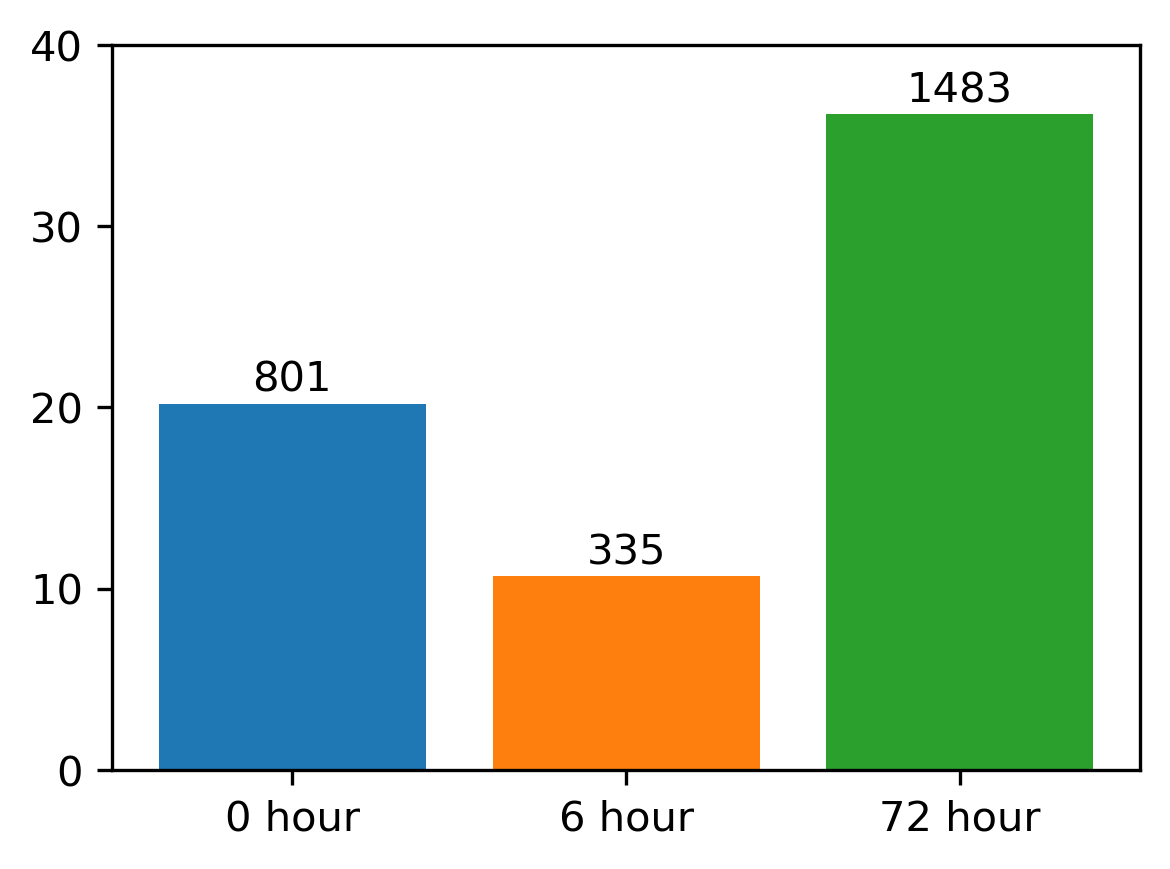

In [13]:
# Percentage of loops only rescued by MEGA in total rescued loops per time point
percent_of_loops_only_rescued_by_MEGA=[]
num_of_loops_only_rescued_by_MEGA=[]

for cond in conditions:
    df_only_rescued_by_MEGA=pd.merge(dots_new, overlapped_loops[cond]['new_only_in_new'], on=['chrom1','start1','end1','chrom2','start2','end2'])
    rescued_by_mega_only_label='&'.join(sorted(set([cond,'MEGA'])))
    percent_of_loops_only_rescued_by_MEGA.append(sum(df_only_rescued_by_MEGA.sample_name == rescued_by_mega_only_label)*100/len(df_only_rescued_by_MEGA))
    num_of_loops_only_rescued_by_MEGA.append(sum(df_only_rescued_by_MEGA.sample_name == rescued_by_mega_only_label))

cond_labels = ['0 hour', '6 hour', '72 hour']

# Use tab10 colormap
colors = plt.get_cmap('tab10').colors

plt.figure(figsize=(4, 3), dpi=300)
bars = plt.bar(cond_labels, percent_of_loops_only_rescued_by_MEGA, color=colors[:len(cond_labels)])
plt.yticks(range(0,50,10))

# Annotate each bar with its number of loops
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.2,
             num_of_loops_only_rescued_by_MEGA[i], ha='center', va='bottom')

# plt.ylabel('Percentage')
plt.tight_layout()

# # save SVG
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_S6/bar_plot_of_percentage_of_loops_only_rescued_by_MEGA_in_total_rescued_loops_per_time_point_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')


In [4]:
len(overlapped_loops['K562_0000min']['old_in_both'])

4018

In [5]:
len(overlapped_loops['K562_0000min']['new_in_both'])

3826

In [6]:
len(overlapped_loops['K562_0000min']['new_only_in_old_no_filtering'])

4091

In [7]:
len(overlapped_loops['K562_0000min']['new_only_in_new'])

3965

In [8]:
len(overlapped_loops['K562_0000min']['old_only'])
# all singletons that the new method filtered them out, 
# since new method also requires them to share their anchors with other clusters besides pass hiccups filtering (sum of q <=0.02)
# See page 20 "Do we need extra steps for singleton filtering in our new method?"
# in next_lab_meeting_v2.ppt at lab_meeting_11062024 folder

# singletons passed both filerings are 16.
# These 70 singletons only pass hiccups filtering but not share their anchors.

70

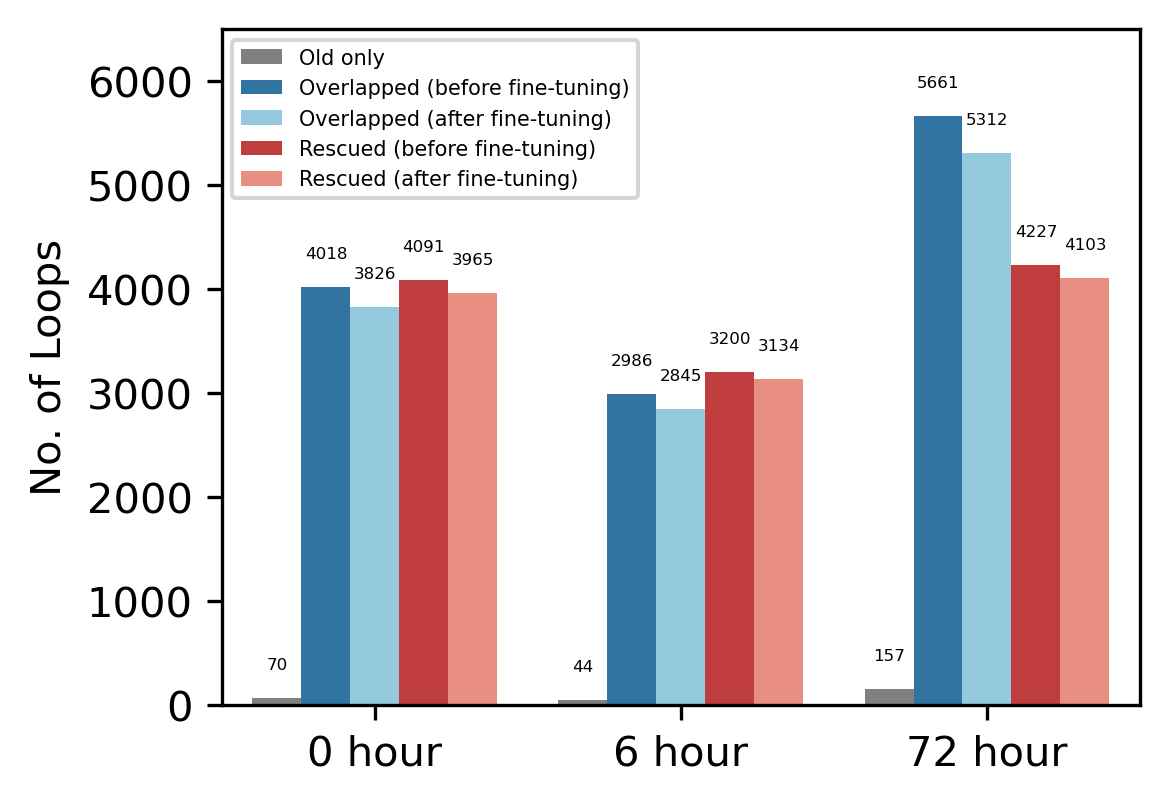

In [10]:
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
methods=['old_only', 'old_in_both', 'new_in_both', 'new_only_in_old_no_filtering', 'new_only_in_new']

Condition=[]
Method=[]
Count=[]

for cond in conditions:
    for method in methods:
        Condition.append(cond)
        Method.append(method)
        Count.append(len(overlapped_loops[cond][method]))
        
data={
    'Condition': Condition,
    'Method': Method,
    'Count': Count
}

df = pd.DataFrame(data)

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='Condition', y='Count', hue='Method', data=df, palette=['grey', '#1f77b4', 'skyblue', '#d62728', 'salmon'])

# Add labels above bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), fontsize=4,
                textcoords='offset points')

# Modify x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])

# Show the plot
# plt.title('Supplemental Figure for Fig2a (workflow): examples (3) and (4)')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Old only', 'Overlapped (before fine-tuning)', 'Overlapped (after fine-tuning)', 'Rescued (before fine-tuning)', 'Rescued (after fine-tuning)'], loc='upper left', fontsize=5)
plt.tight_layout()
plt.ylabel('No. of Loops')
plt.xlabel('')
plt.ylim(0,6500)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/bar_plot_of_numbers_of_loops_per_category_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

# old_only loops only pass hiccups filtering (sum of q <=0.02) but do not not share their anchors.

In [ ]:
# since the number of old_only is too small, so we do not show them in the pie chart.
# In other words, we almost accept all HiCCUPS's conservative and strong loops (true positive).

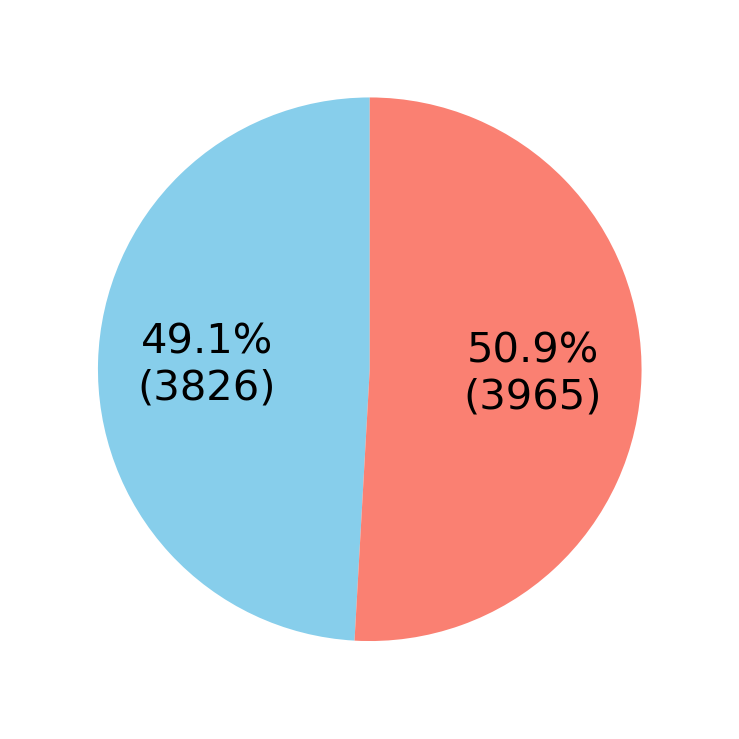

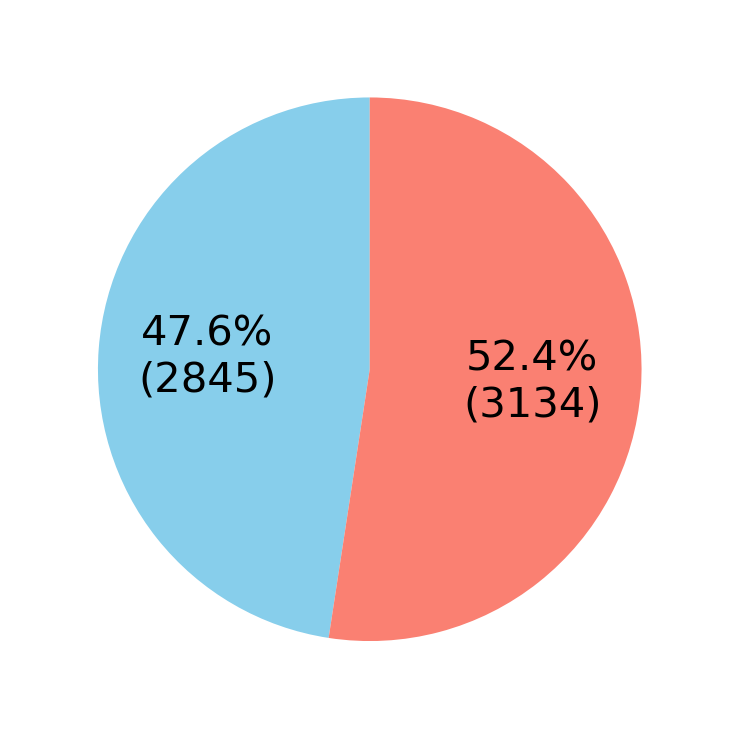

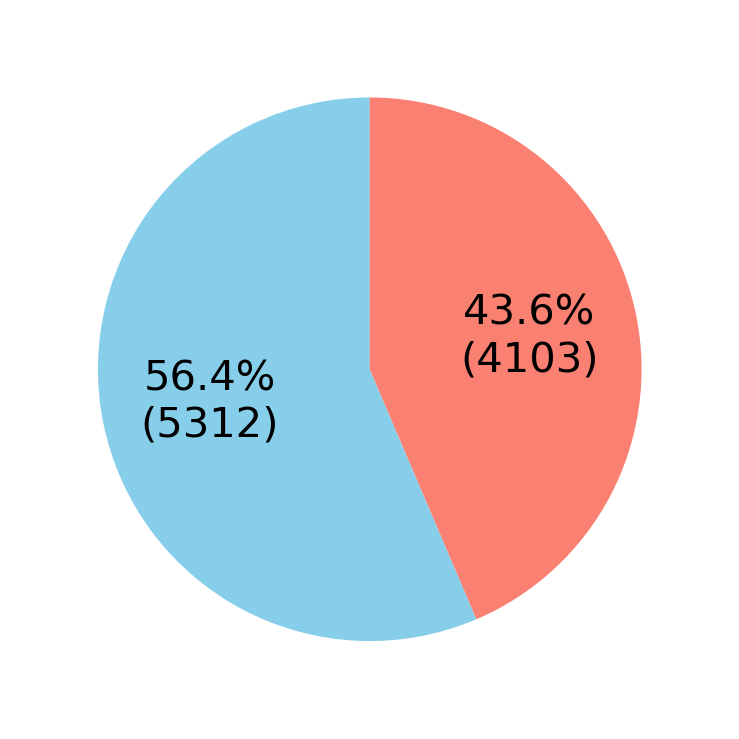

In [12]:
import matplotlib.pyplot as plt

labels = ['Overlapped', 'Rescued']
for cond in conditions:
    sizes = [len(overlapped_loops[cond]['new_in_both']), len(overlapped_loops[cond]['new_only_in_new'])]  # Values for each part
    colors = ['skyblue','salmon']
#     # Custom labels with sizes
#     custom_labels = [f'{label}:\n{size}' for label, size in zip(labels, sizes)]

    # Create pie chart
    plt.figure(figsize=(3, 3), dpi=300)
    plt.pie(sizes, 
        autopct=lambda p: f'{p:.1f}%\n({p * sum(sizes) / 100:.0f})', 
#         colors=colors, startangle=90, textprops={'fontsize': 12})
        colors=colors, startangle=90)
#     # save svg
#     plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/pie_chart_of_overlapped_and_rescued_loops_at_{cond}_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')
    
    # Title
#     plt.title(cond, fontsize=18)
    

### Generate pileup plots of overlapped (before and after fine-tuning) and rescued (before and after fine-tuning) per time point (4 plots).

In [20]:
# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/Bond_et_al_2023/generate_matrices_of_pileup_plots_of_overlapped_and_rescued_loops_before_and_after_fine_tuning_at_0_6_72h.py"


INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <281129> is submitted to queue <long>.


In [13]:
pileup_mtx='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/pileup_matrices_of_overlapped_and_rescued_loops_before_and_after_fine_tuning_at_0_6_72h.pickle'
with open(pileup_mtx, 'rb') as f:
    pileup_mtx = pickle.load(f)

In [14]:
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))

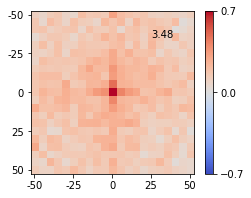

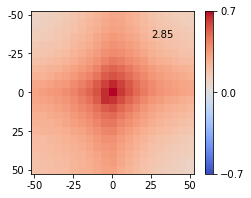

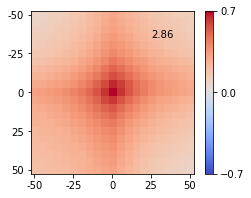

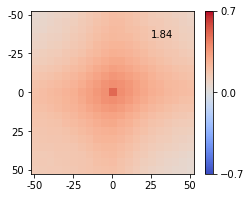

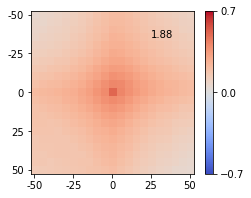

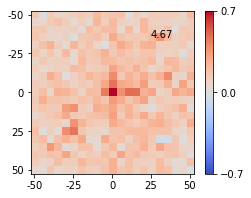

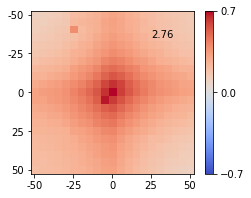

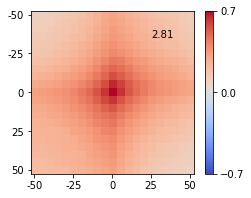

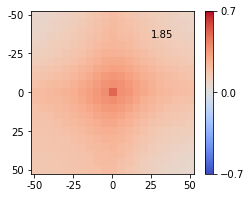

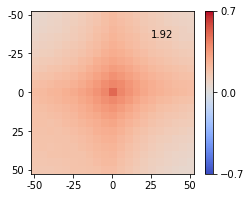

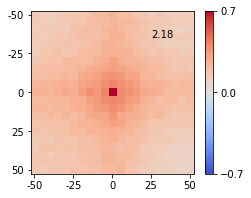

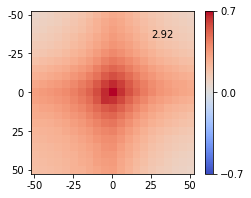

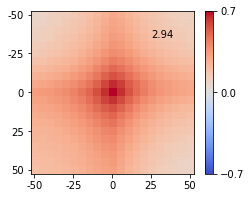

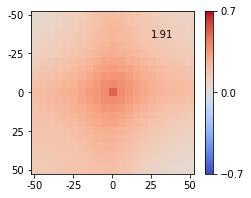

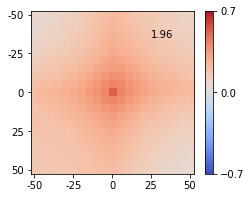

In [16]:
resolution=5000
flank=50000
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
methods=['old_only', 'old_in_both', 'new_in_both', 'new_only_in_old_no_filtering', 'new_only_in_new']
labels={'old_in_both': 'overlapped_loops_before_fine_tuning',
        'new_in_both': 'overlapped_loops_after_fine_tuning',
        'new_only_in_old_no_filtering': 'rescued_loops_before_fine_tuning',
        'new_only_in_new': 'rescued_loops_after_fine_tuning'}

for cond in conditions:
    for method in methods:
        label=f'{cond}_{method}'
        plt.figure(figsize=(4, 3))
        img=plt.imshow(
            np.log10(pileup_mtx[label]),
            vmin = -0.7,
            vmax = 0.7,
            cmap='coolwarm')
#         plt.text(15, 3, round(quantify_loops(pileup_mtx[label]),2), fontsize=20)
        plt.text(15, 3, round(quantify_loops(pileup_mtx[label]),2))
        
#         plt.colorbar(label = 'log10 mean obs/exp')
        cbar = plt.colorbar(img, label='')  # Capture the colorbar object
        cbar.set_ticks([-0.7, 0, 0.7])     # Set ticks manually
        ticks_pixels = np.linspace(0, flank*2//resolution,5)
        ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
        plt.xticks(ticks_pixels, ticks_kbp)
        plt.yticks(ticks_pixels, ticks_kbp)
#         plt.xlabel('relative position, kb')
#         plt.ylabel('relative position, kb')
#         plt.title(label)
        
# #         save svg
#         if method != 'old_only':
#             plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/pileup_plot_of_{labels[method]}_at_{cond}_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')


### Generate box plots of loop strength of overlapped (before and after fine-tuning) and rescued (before and after fine-tuning) per time point.

In [29]:
# calculate loop strength of loops (old 5kb without filtering)
input_cooler_paths='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/cooler_paths_of_Bond_et_al_2023.tsv'
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/'
dots_file=dots_dir+'union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering.txt'
libraries_names='K562_0000min,K562_0360min,K562_4320min,MEGA'
resolution=5000
flank=50000
output=dots_dir+'loop_strength_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering.txt'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/calculate_loop_strength_in_multiple_samples.py $input_cooler_paths $dots_file $libraries_names $resolution $flank $output"


INFO: Total memory requested is 64000 MB (8 cores x 8000 MB)
Job <279337> is submitted to queue <long>.


In [17]:
# loop strength
# old no filtering
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_old/centroids/'
loop_strength_old=pd.read_csv(dots_dir+'loop_strength_of_union_dot_list_of_Bond_et_al_2023_5kb_old_method_no_HiCCUPS_filtering.txt', sep='\t')

dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Bond_et_al_2023_union_loop_list_5kb.tsv'
loop_strength_new=pd.read_csv(dots_file, sep='\t').drop(columns=['sample_name'])

loop_strength_old_new=pd.concat([loop_strength_old, loop_strength_new], ignore_index=True).drop_duplicates(subset=['chrom1','start1','end1','chrom2','start2','end2']).reset_index(drop=True)


In [18]:
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
methods=['old_only', 'old_in_both', 'new_in_both', 'new_only_in_old_no_filtering', 'new_only_in_new']

loops_list=[]
for cond in conditions:
    for method in methods:
        df=overlapped_loops[cond][method].drop(columns=['region', 'c_label', 'c_size'])
        df['method']=method
        df['condition']=cond
        loops_list.append(df)
loops_df=pd.concat(loops_list, ignore_index=True)

In [19]:
loops_df_loop_strength=pd.merge(loops_df, loop_strength_old_new, on=['chrom1','start1','end1','chrom2','start2','end2'])

In [20]:
loop_strength_list=[]
for cond in conditions:
    for method in methods:
        df=loops_df_loop_strength.loc[(loops_df_loop_strength.condition == cond) & (loops_df_loop_strength.method == method)]
        df=df[['chrom1','start1','end1','chrom2','start2','end2','condition','method']+[cond]]
        df=df.rename({cond: 'loop_strength'}, axis='columns')
        loop_strength_list.append(df)
loop_strength_df=pd.concat(loop_strength_list, ignore_index=True)


(0.0, 6.0)

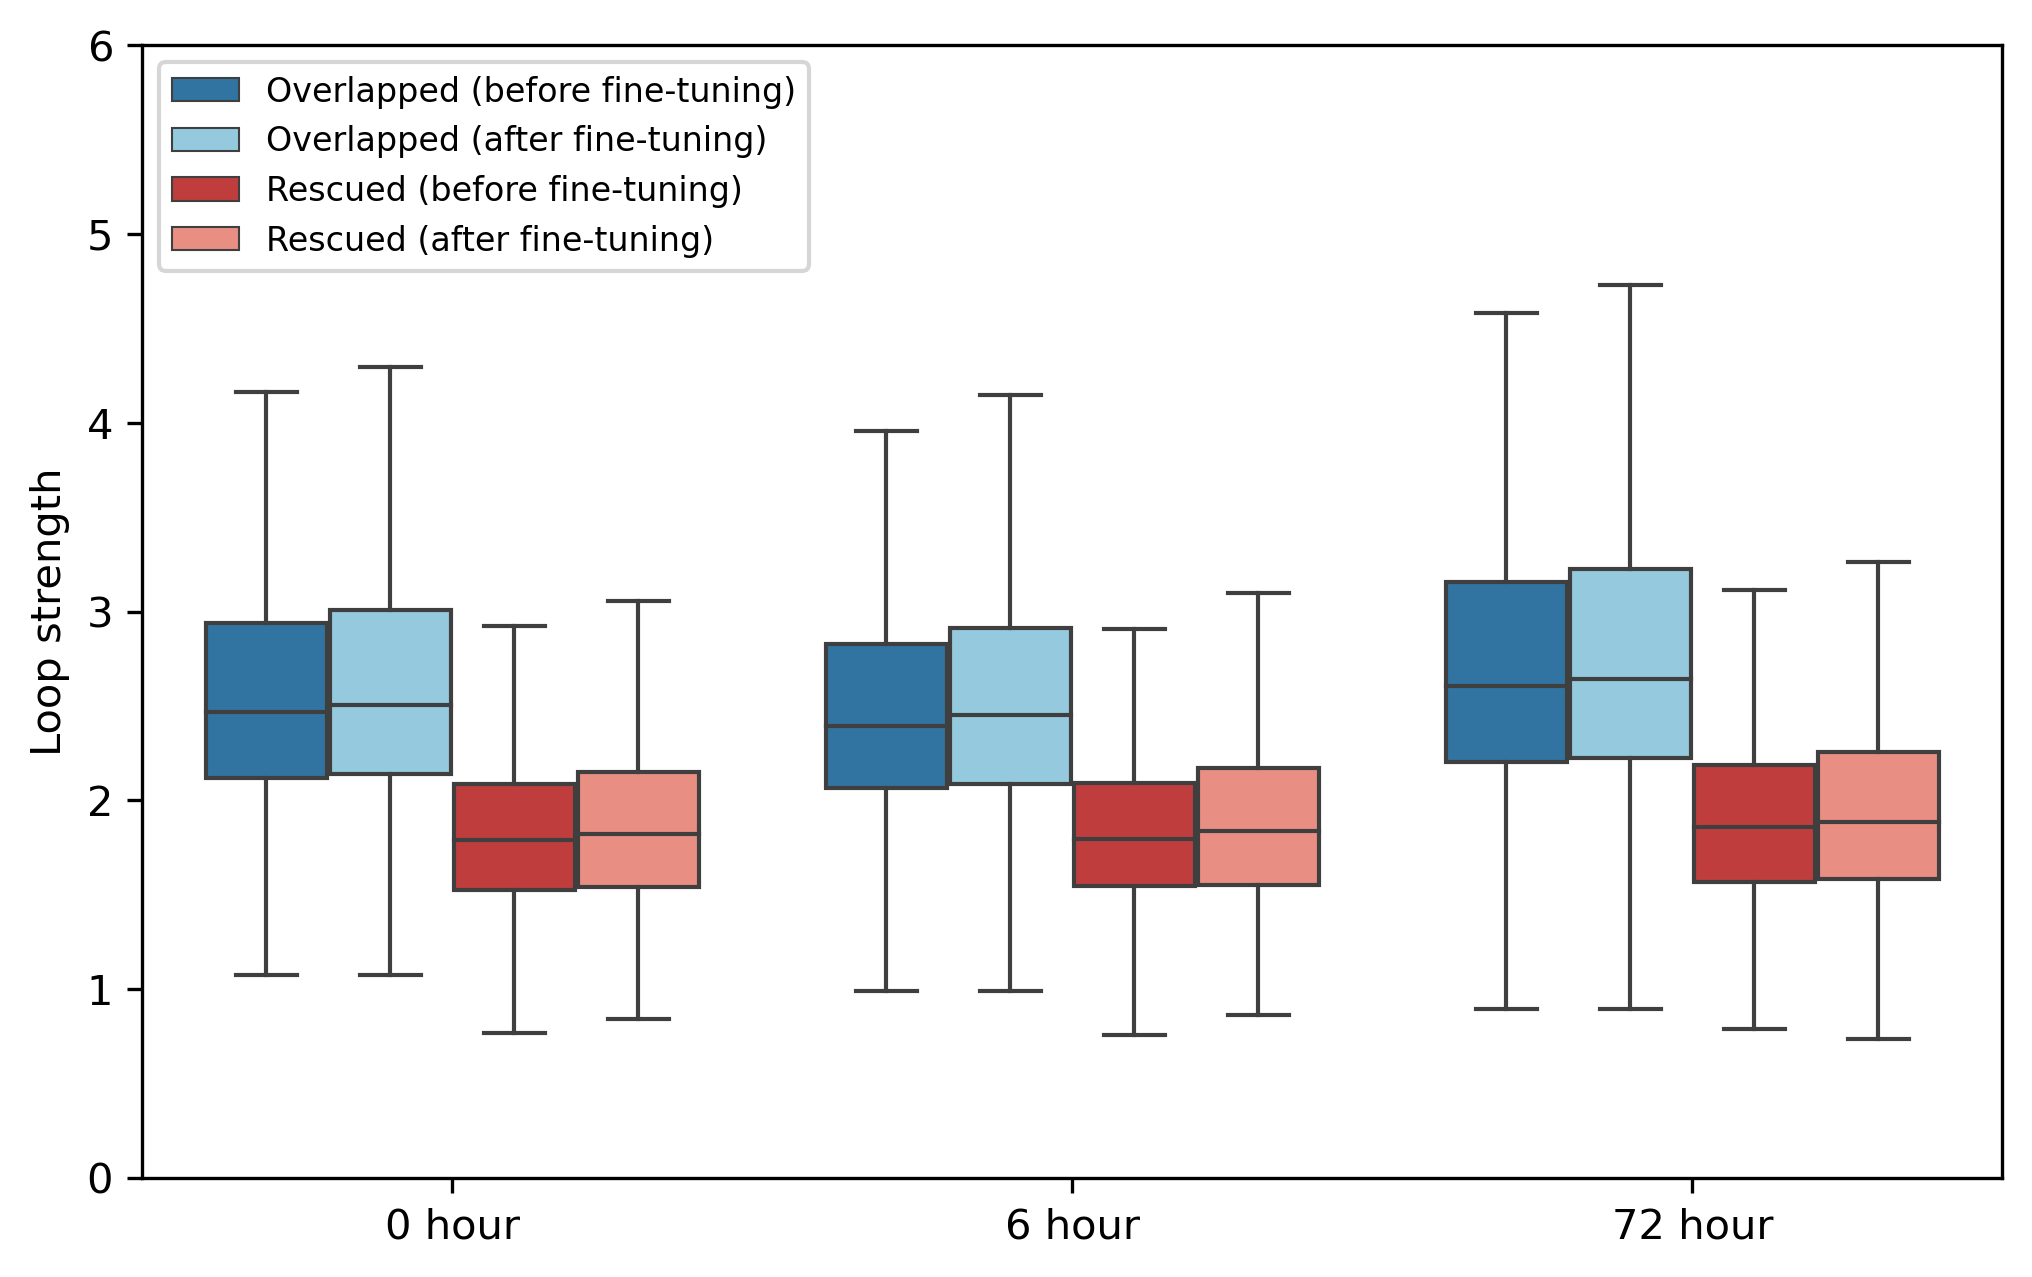

In [21]:
import seaborn as sns
from matplotlib import pyplot as plt

fig = plt.figure(dpi=300, figsize=(8,5))
sns.set_palette(('#1f77b4', 'skyblue', '#d62728', 'salmon'))
ax=sns.boxplot(x='condition', y='loop_strength', hue='method', showfliers=False, data=loop_strength_df.loc[loop_strength_df.method != 'old_only'], linewidth=1)
ax.set(xlabel=None)
ax.set_ylabel('Loop strength', size=10)
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'], fontsize=10)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Overlapped (before fine-tuning)', 'Overlapped (after fine-tuning)', 'Rescued (before fine-tuning)', 'Rescued (after fine-tuning)'], loc='upper left', fontsize=8, ncol=1)
plt.ylim(0,6)


In [22]:
from scipy.stats import ranksums
# The Wilcoxon rank-sum test tests the null hypothesis that two sets of measurements are drawn 
# from the same distribution. The alternative hypothesis is that values in one sample are more 
# likely to be larger than the values in the other sample.

# The Wilcoxon Rank-Sum test is still valid for data from any distribution, whether Normal or not, and 
# is much less sensitive to outliers than the two-sample t-test.

# statistic < 0, prior is smaller
pairwise_compare={}
for cond in conditions:
    pairwise_compare[f'{cond}: overlapped (before vs after fine-tuning)']=ranksums(loop_strength_df.loc[(loop_strength_df['condition'] == cond) & (loop_strength_df['method'] == 'old_in_both'), 'loop_strength'], 
                                                            loop_strength_df.loc[(loop_strength_df['condition'] == cond) & (loop_strength_df['method'] == 'new_in_both'), 'loop_strength'])
    pairwise_compare[f'{cond}: rescued (before vs after fine-tuning)']=ranksums(loop_strength_df.loc[(loop_strength_df['condition'] == cond) & (loop_strength_df['method'] == 'new_only_in_old_no_filtering'), 'loop_strength'], 
                                                            loop_strength_df.loc[(loop_strength_df['condition'] == cond) & (loop_strength_df['method'] == 'new_only_in_new'), 'loop_strength'])
    

In [23]:
pairwise_compare # all significant (p < 0.05)

{'K562_0000min: overlapped (before vs after fine-tuning)': RanksumsResult(statistic=-2.5947545900662363, pvalue=0.009465847991396544),
 'K562_0000min: rescued (before vs after fine-tuning)': RanksumsResult(statistic=-3.1170971197281587, pvalue=0.001826413929125098),
 'K562_0360min: overlapped (before vs after fine-tuning)': RanksumsResult(statistic=-2.7899951402024996, pvalue=0.005270883271995534),
 'K562_0360min: rescued (before vs after fine-tuning)': RanksumsResult(statistic=-3.9259823361385586, pvalue=8.637649446835835e-05),
 'K562_4320min: overlapped (before vs after fine-tuning)': RanksumsResult(statistic=-2.769639896152516, pvalue=0.005611829889120574),
 'K562_4320min: rescued (before vs after fine-tuning)': RanksumsResult(statistic=-3.002368715825166, pvalue=0.002678874926303504)}

In [24]:
for i, j in pairwise_compare.items():
    print(f"{i}: {'*' if j.pvalue < 0.05 else 'ns'}")

K562_0000min: overlapped (before vs after fine-tuning): *
K562_0000min: rescued (before vs after fine-tuning): *
K562_0360min: overlapped (before vs after fine-tuning): *
K562_0360min: rescued (before vs after fine-tuning): *
K562_4320min: overlapped (before vs after fine-tuning): *
K562_4320min: rescued (before vs after fine-tuning): *


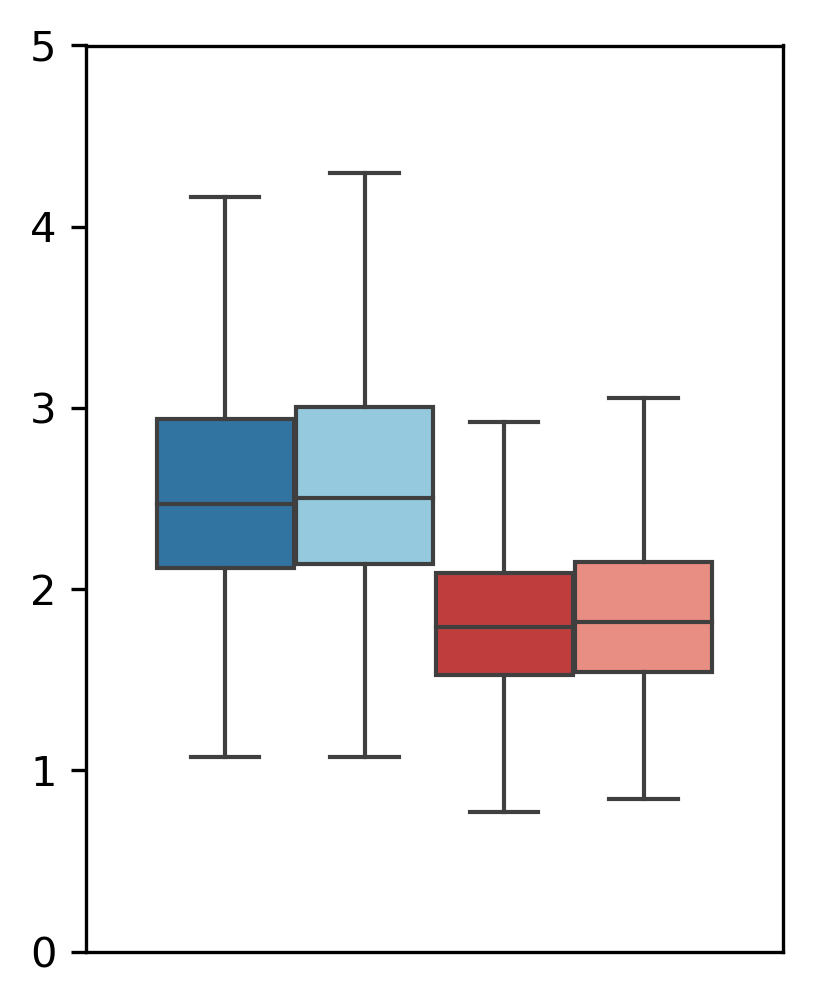

In [25]:
# 0 hour
import seaborn as sns
from matplotlib import pyplot as plt

filtered_df = loop_strength_df.loc[(loop_strength_df.method != 'old_only') & (loop_strength_df.condition == 'K562_0000min')]
fig = plt.figure(dpi=300, figsize=(3,4))
sns.set_palette(('#1f77b4', 'skyblue', '#d62728', 'salmon'))
ax=sns.boxplot(x='condition', y='loop_strength', hue='method', showfliers=False, data=filtered_df, linewidth=1)
ax.set(xlabel=None, ylabel=None)
# ax.set_xticklabels(['0 hour', '6 hour', '72 hour'], fontsize=10)

# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(handles, ['Before fine-tuning', 'After fine-tuning', 'Rescued'], loc='upper left', fontsize=8, ncol=1)
plt.ylim(0,5)

ax.legend_.remove()
ax.set_xticks([])
ax.set_xticklabels([])

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/box_plot_of_loop_strength_of_before_and_after_fine_tuning_loops_at_K562_0000min_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')


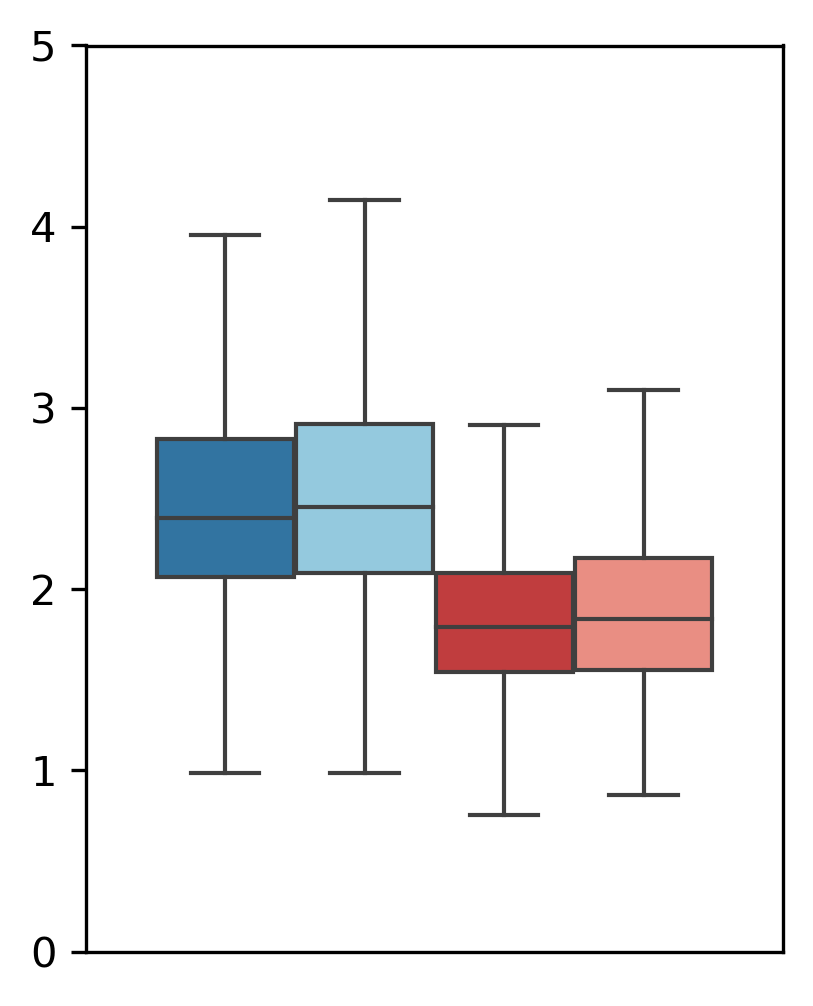

In [26]:
# 6 hour
import seaborn as sns
from matplotlib import pyplot as plt

filtered_df = loop_strength_df.loc[(loop_strength_df.method != 'old_only') & (loop_strength_df.condition == 'K562_0360min')]
fig = plt.figure(dpi=300, figsize=(3,4))
sns.set_palette(('#1f77b4', 'skyblue', '#d62728', 'salmon'))
ax=sns.boxplot(x='condition', y='loop_strength', hue='method', showfliers=False, data=filtered_df, linewidth=1)
ax.set(xlabel=None, ylabel=None)
# ax.set_xticklabels(['0 hour', '6 hour', '72 hour'], fontsize=10)

# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(handles, ['Before fine-tuning', 'After fine-tuning', 'Rescued'], loc='upper left', fontsize=8, ncol=1)
plt.ylim(0,5)

ax.legend_.remove()
ax.set_xticks([])
ax.set_xticklabels([])

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/box_plot_of_loop_strength_of_before_and_after_fine_tuning_loops_at_K562_0360min_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')


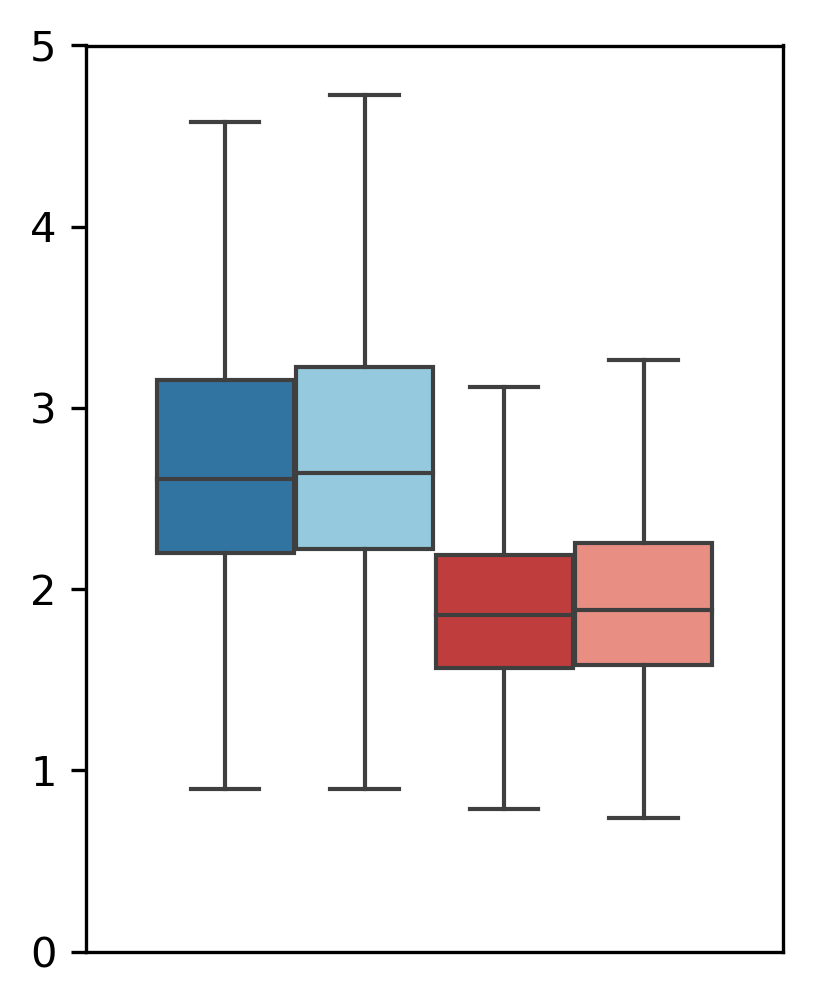

In [27]:
# 72 hour
import seaborn as sns
from matplotlib import pyplot as plt

filtered_df = loop_strength_df.loc[(loop_strength_df.method != 'old_only') & (loop_strength_df.condition == 'K562_4320min')]
fig = plt.figure(dpi=300, figsize=(3,4))
sns.set_palette(('#1f77b4', 'skyblue', '#d62728', 'salmon'))
ax=sns.boxplot(x='condition', y='loop_strength', hue='method', showfliers=False, data=filtered_df, linewidth=1)
ax.set(xlabel=None, ylabel=None)
# ax.set_xticklabels(['0 hour', '6 hour', '72 hour'], fontsize=10)

# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(handles, ['Before fine-tuning', 'After fine-tuning', 'Rescued'], loc='upper left', fontsize=8, ncol=1)
plt.ylim(0,5)

ax.legend_.remove()
ax.set_xticks([])
ax.set_xticklabels([])

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/box_plot_of_loop_strength_of_before_and_after_fine_tuning_loops_at_K562_4320min_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')


## Compare percentage of anchors overlapped with CNR peaks between before and after fine-tune loops

/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/cut_and_run/merged/ <br>
Merged narrowPeak files from the email from the author: <br>
Subject: Questions about in situ Hi-C data during differentiation of K562 cells at 0, 6, and 72 h. <br>
marielle_bond@med.unc.edu <br>
for_jiangyuan.zip <br>
<br>
Supplemental_Methods_.docx <br>
"For each timepoint, biological replicates were merged and indexed with SAMtools. We called peaks on the merged files using MACS2 with the following parameters: -f BAM -q 0.01 -g hs --nomodel --shift 0 --extsize 200 --keep-dup all -B --SPMR (version 2.1.1.20160309) (Zhang et al. 2008)."

In [17]:
# merged peak files CNR (two replicates)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']

CNR_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/cut_and_run/merged/'
ctcf_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_CTCF_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

# Note: K562_0360min does not have rad21 data
rad21_peak_file={
    'K562_0000min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_4320min': CNR_dir+'MEGA_ChIP_Rad21_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

atac_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Bond_et_al_2023/ATAC_Seq/merged/'
atac_peak_file={
    'K562_0000min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_0_S_peaks.narrowPeak',
    'K562_0360min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_360_S_peaks.narrowPeak',
    'K562_4320min': atac_dir+'MERGE_MEGA_ATAC_ATAC_K562_WT_PMA_4320_S_peaks.narrowPeak'
}

methods=['old_in_both', 'new_in_both', 'new_only_in_old_no_filtering', 'new_only_in_new']

In [18]:
all_anchors=[]
for cond in conditions:
    for method in methods:
        loops_df=overlapped_loops[cond][method][['chrom1','start1','end1','chrom2','start2','end2']].copy().reset_index(drop=True)
        anchor1=loops_df[['chrom1','start1','end1']].copy().set_axis(['chrom','start','end'], axis=1)
        anchor2=loops_df[['chrom2','start2','end2']].copy().set_axis(['chrom','start','end'], axis=1)
        anchors=pd.concat([anchor1, anchor2], ignore_index=True).drop_duplicates().reset_index(drop=True)
        anchors['condition']=cond
        anchors['method']=method
        all_anchors.append(anchors)
        
all_anchors=pd.concat(all_anchors, ignore_index=True)

In [6]:
import bioframe
import pandas as pd
import numpy as np

def calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors):
    anchors_overlapped_with_peaks={'condition': [],
                                   'method': [],
                                   'count': [],
                                   'total': [],
                                   'percent': []
                                  }

    for cond in conditions:
        for method in methods:
            anchors_overlapped_with_peaks['condition'].append(cond)
            anchors_overlapped_with_peaks['method'].append(method)
            anchors=all_anchors.loc[(all_anchors.condition == cond) & (all_anchors.method == method), ['chrom','start','end']]
            anchors_overlapped_with_peaks['total'].append(len(anchors))

            peak_df=pd.read_csv(peak_file[cond],sep='\t',header=None).iloc[:,:3]
            peak_df.columns=['chrom','start','end']
            overlapped_anchors=bioframe.overlap(anchors, peak_df, how='inner', suffixes=("","_"))[['chrom','start','end']].drop_duplicates().reset_index(drop=True)    
            anchors_overlapped_with_peaks['count'].append(len(overlapped_anchors))
            anchors_overlapped_with_peaks['percent'].append(100*len(overlapped_anchors)/len(anchors))

    anchors_overlapped_with_peaks=pd.DataFrame(anchors_overlapped_with_peaks)
    return anchors_overlapped_with_peaks
    
    


In [7]:
# CTCF
peak_file=ctcf_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_CTCF_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# Rad21
# No K562_0360min
peak_file=rad21_peak_file
conditions=['K562_0000min',
#             'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_rad21_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)

# atac
peak_file=atac_peak_file
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
anchors_overlapped_with_atac_peaks=calculate_number_of_overlapped_anchors_with_peaks(conditions, methods, peak_file, all_anchors)



['*', '*', '*']
['*', '*', '*']


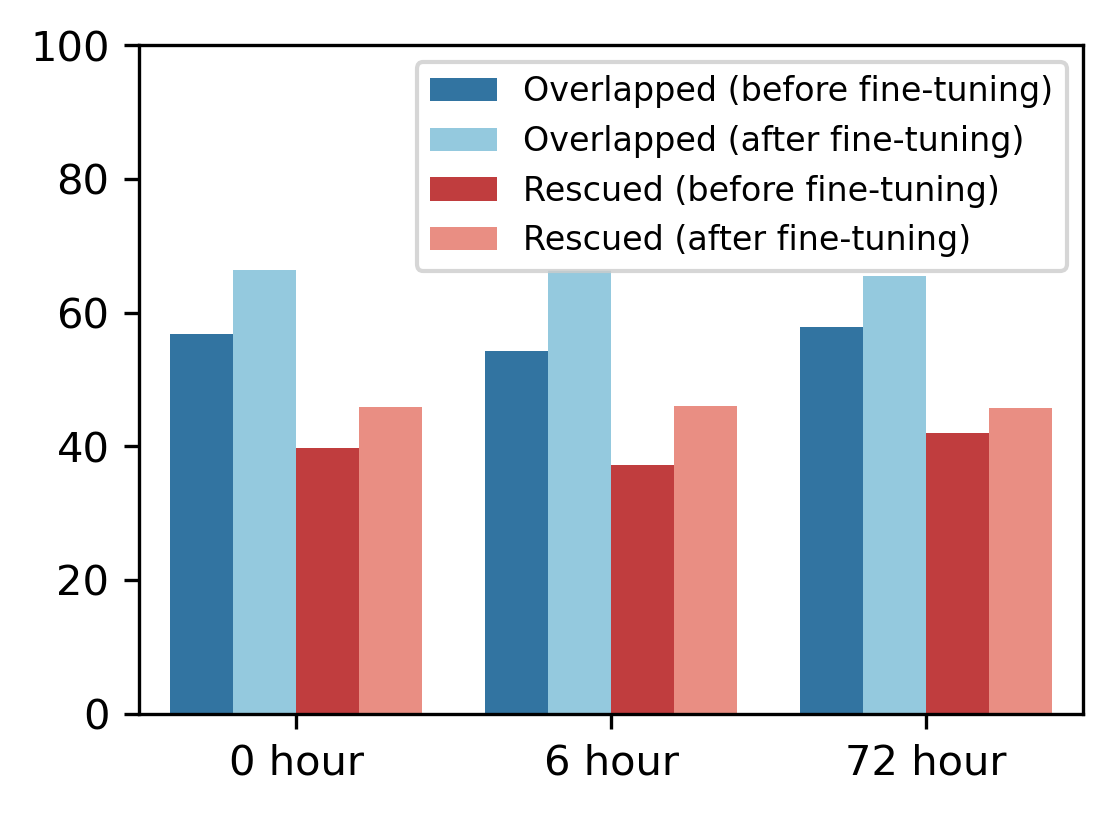

In [8]:
# CTCF
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_CTCF_peaks, hue_order=methods, palette=['#1f77b4', 'skyblue', '#d62728', 'salmon'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (old_in_both vs new_in_both)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
p_labels_old_in_both=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_old_in_both.append(p_label)

# chi2 test (new_only_in_old_no_filtering vs new_only_in_new)
p_labels_new_only=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_CTCF_peaks.loc[anchors_overlapped_with_CTCF_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]], [df_pair.iloc[3, 2], df_pair.iloc[3, 3]-df_pair.iloc[3, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_new_only.append(p_label)

# # Add labels above bars
# for i, p in enumerate(ax.patches):
#     if i in list(range(len(conditions),len(conditions)*2)):
#         ax.annotate(f'{p.get_height():.1f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions))): # (old_in_both vs new_in_both)
#         ax.annotate(f'{p_labels_old_in_both.pop(0)}\n\n{p.get_height():.1f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+5), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions)*2,len(conditions)*3)): # (new_in_both vs new_only)
#         ax.annotate(f'{p_labels_new_only.pop(0)}\n\n{p.get_height():.1f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+5), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')

# # Add labels above bars
# for i, p in enumerate(ax.patches):
#     if i in list(range(len(conditions),len(conditions)*2)):
#         ax.annotate('', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions))): # (old_in_both vs new_in_both)
#         ax.annotate(f'{p_labels_old_in_both.pop(0)}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+2), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions)*2,len(conditions)*3)): # (new_in_both vs new_only)
#         ax.annotate(f'{p_labels_new_only.pop(0)}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+2), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')

# Show the plot
# plt.title('Percentage of 5kb anchors overlapped with CTCF CNR peaks', fontsize=10)
# Get the current legend and update its labels
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Overlapped (before fine-tuning)', 'Overlapped (after fine-tuning)', 'Rescued (before fine-tuning)', 'Rescued (after fine-tuning)'], loc='upper right', fontsize=8)
# plt.text(0.65, 94, 'Chi-square test\n*: significantly different\nns: non-significantly different', ha='left', fontsize=8, bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/bar_plot_of_percentage_of_5kb_anchors_overlapped_with_CTCF_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(p_labels_old_in_both)
print(p_labels_new_only)

['*', '*']
['*', 'ns']


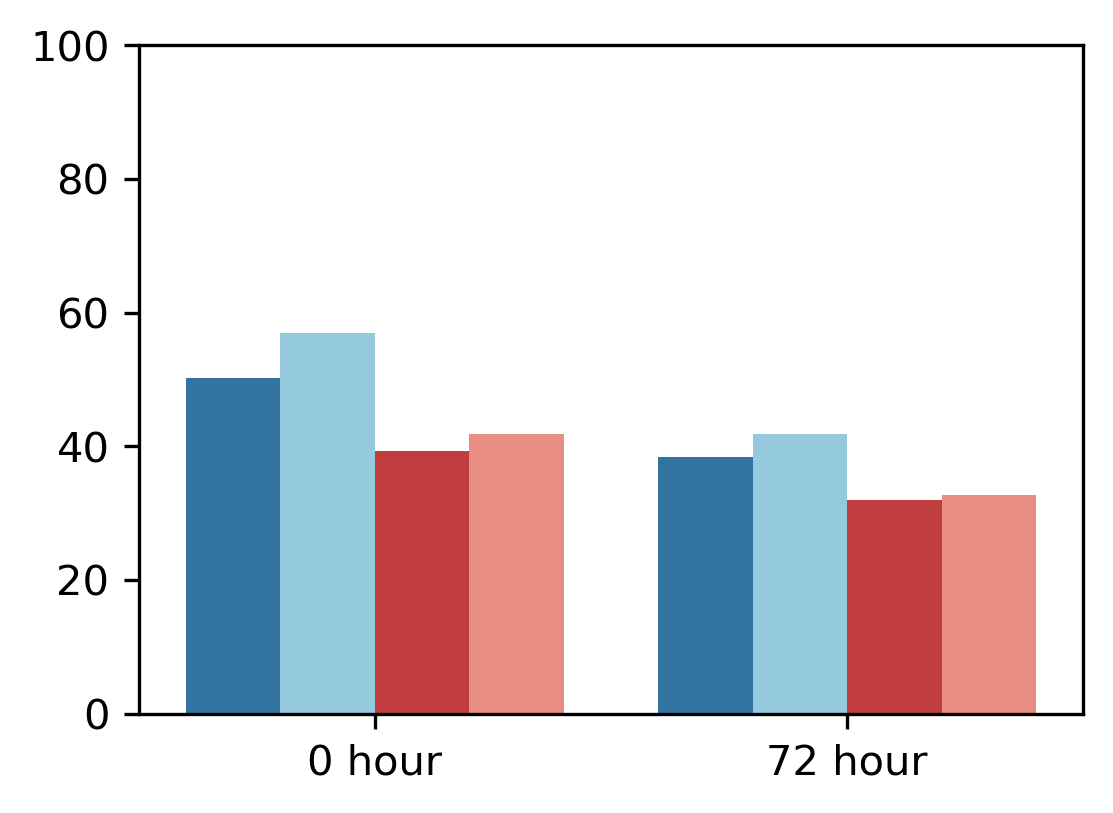

In [33]:
# rad21
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_rad21_peaks, hue_order=methods, palette=['#1f77b4', 'skyblue', '#d62728', 'salmon'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (old_in_both vs new_in_both)
conditions=['K562_0000min',
#             'K562_0360min',
            'K562_4320min']
p_labels_old_in_both=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_old_in_both.append(p_label)

# chi2 test (new_only_in_old_no_filtering vs new_only_in_new)
p_labels_new_only=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_rad21_peaks.loc[anchors_overlapped_with_rad21_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]], [df_pair.iloc[3, 2], df_pair.iloc[3, 3]-df_pair.iloc[3, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_new_only.append(p_label)

# # Add labels above bars
# for i, p in enumerate(ax.patches):
#     if i in list(range(len(conditions),len(conditions)*2)):
#         ax.annotate(f'{p.get_height():.1f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions))): # (old_in_both vs new_in_both)
#         ax.annotate(f'{p_labels_old_in_both.pop(0)}\n\n{p.get_height():.1f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+5), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions)*2,len(conditions)*3)): # (new_in_both vs new_only)
#         ax.annotate(f'{p_labels_new_only.pop(0)}\n\n{p.get_height():.1f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+5), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')

# # Add labels above bars
# for i, p in enumerate(ax.patches):
#     if i in list(range(len(conditions),len(conditions)*2)):
#         ax.annotate('', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions))): # (old_in_both vs new_in_both)
#         ax.annotate(f'{p_labels_old_in_both.pop(0)}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+2), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions)*2,len(conditions)*3)): # (new_in_both vs new_only)
#         ax.annotate(f'{p_labels_new_only.pop(0)}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+2), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')

ax.legend_.remove()

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/bar_plot_of_percentage_of_5kb_anchors_overlapped_with_Rad21_CNR_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(p_labels_old_in_both)
print(p_labels_new_only)

['*', '*', '*']
['*', '*', 'ns']


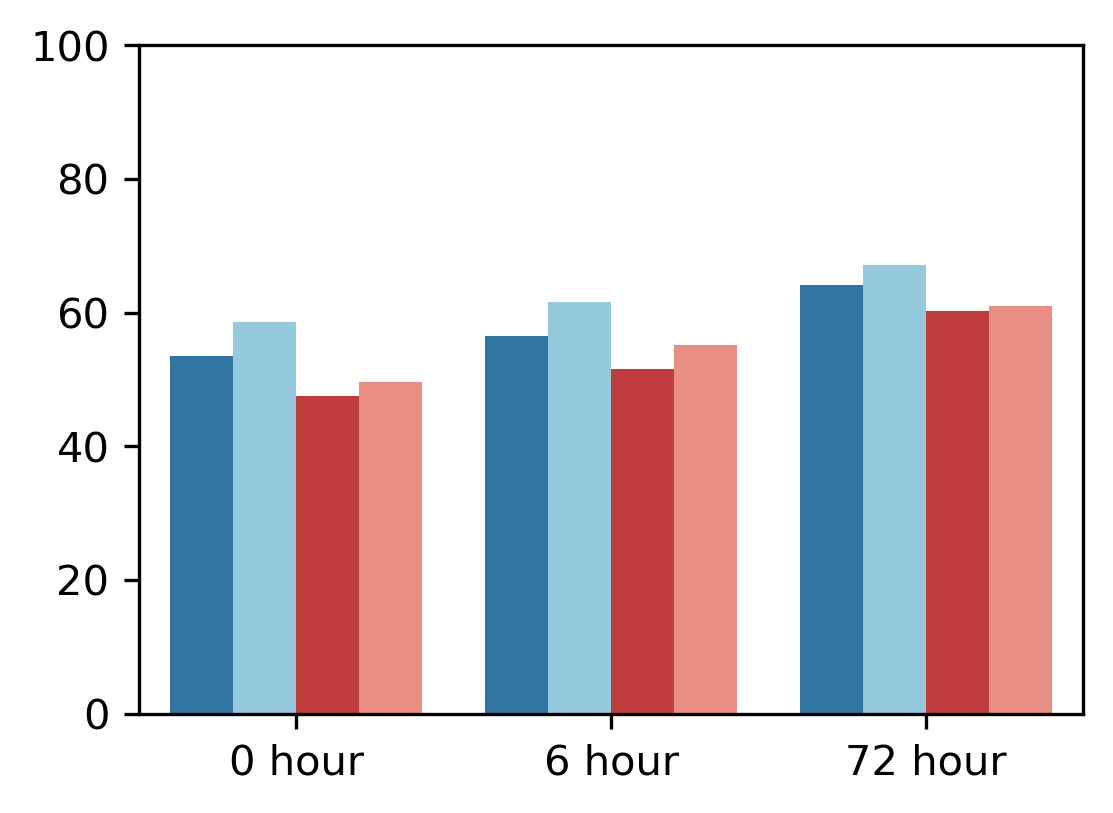

In [35]:
# atac
from scipy.stats import chi2_contingency

# Create the grouped bar plot
plt.figure(figsize=(4, 3), dpi=300)
ax = sns.barplot(x='condition', y='percent', hue='method', data=anchors_overlapped_with_atac_peaks, hue_order=methods, palette=['#1f77b4', 'skyblue', '#d62728', 'salmon'])

# Set custom x-tick labels
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
ax.set_yticks(range(0, 101, 20))

# chi2 test (old_in_both vs new_in_both)
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
p_labels_old_in_both=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[0, 2], df_pair.iloc[0, 3]-df_pair.iloc[0, 2]], [df_pair.iloc[1, 2], df_pair.iloc[1, 3]-df_pair.iloc[1, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_old_in_both.append(p_label)

# chi2 test (new_only_in_old_no_filtering vs new_only_in_new)
p_labels_new_only=[] # '' for not significant, '*' for significant
for cond in conditions:
    df_pair=anchors_overlapped_with_atac_peaks.loc[anchors_overlapped_with_atac_peaks.condition == cond].copy().reset_index(drop=True)
    data = [[df_pair.iloc[2, 2], df_pair.iloc[2, 3]-df_pair.iloc[2, 2]], [df_pair.iloc[3, 2], df_pair.iloc[3, 3]-df_pair.iloc[3, 2]]]
    stat, p, dof, expected = chi2_contingency(data)
    p_label='*' if p < 0.05 else 'ns'
    p_labels_new_only.append(p_label)

# # Add labels above bars
# for i, p in enumerate(ax.patches):
#     if i in list(range(len(conditions),len(conditions)*2)):
#         ax.annotate(f'{p.get_height():.1f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions))): # (old_in_both vs new_in_both)
#         ax.annotate(f'{p_labels_old_in_both.pop(0)}\n\n{p.get_height():.1f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+5), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions)*2,len(conditions)*3)): # (new_in_both vs new_only)
#         ax.annotate(f'{p_labels_new_only.pop(0)}\n\n{p.get_height():.1f}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+5), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')

# # Add labels above bars
# for i, p in enumerate(ax.patches):
#     if i in list(range(len(conditions),len(conditions)*2)):
#         ax.annotate('', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions))): # (old_in_both vs new_in_both)
#         ax.annotate(f'{p_labels_old_in_both.pop(0)}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+2), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')
#     elif i in list(range(len(conditions)*2,len(conditions)*3)): # (new_in_both vs new_only)
#         ax.annotate(f'{p_labels_new_only.pop(0)}', 
#                     (p.get_x() + p.get_width() / 2., p.get_height()+2), 
#                     ha='center', va='center', xytext=(0, 8), 
#                     textcoords='offset points')

ax.legend_.remove()

plt.tight_layout()
# plt.ylabel('Percentage')
plt.ylabel('')
plt.xlabel('')
plt.ylim(0, 100)

# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/bar_plot_of_percentage_of_5kb_anchors_overlapped_withc_peaks_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')

print(p_labels_old_in_both)
print(p_labels_new_only)

### Compare distributions of loop size between after fine-tune and rescued loops

In [50]:
conditions=['K562_0000min',
            'K562_0360min',
            'K562_4320min']
methods=['new_in_both', 'new_only_in_new']
loop_size_list=[]
for cond in conditions:
    for method in methods:
        df=overlapped_loops[cond][method][['chrom1','start1','end1','chrom2','start2','end2']]
        df['method']=method
        df['condition']=cond
        df['loop_size']=df['start2']-df['start1']
        loop_size_list.append(df)
loop_size_df=pd.concat(loop_size_list)


/tmp/ipykernel_3898004/1091975243.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['method']=method
/tmp/ipykernel_3898004/1091975243.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['condition']=cond


In [51]:
from scipy.stats import ranksums
# The Wilcoxon rank-sum test tests the null hypothesis that two sets of measurements are drawn 
# from the same distribution. The alternative hypothesis is that values in one sample are more 
# likely to be larger than the values in the other sample.

# The Wilcoxon Rank-Sum test is still valid for data from any distribution, whether Normal or not, and 
# is much less sensitive to outliers than the two-sample t-test.

p_values=[]
for cond in conditions:
    p_value=ranksums(loop_size_df.loc[(loop_size_df['condition'] == cond) & (loop_size_df['method'] == 'new_in_both'), 'loop_size'], 
                     loop_size_df.loc[(loop_size_df['condition'] == cond) & (loop_size_df['method'] == 'new_only_in_new'), 'loop_size']).pvalue
    p_values.append(p_value)


In [52]:
p_values

[1.0663751614873477e-118, 9.108897730149986e-65, 4.9785060445422053e-147]

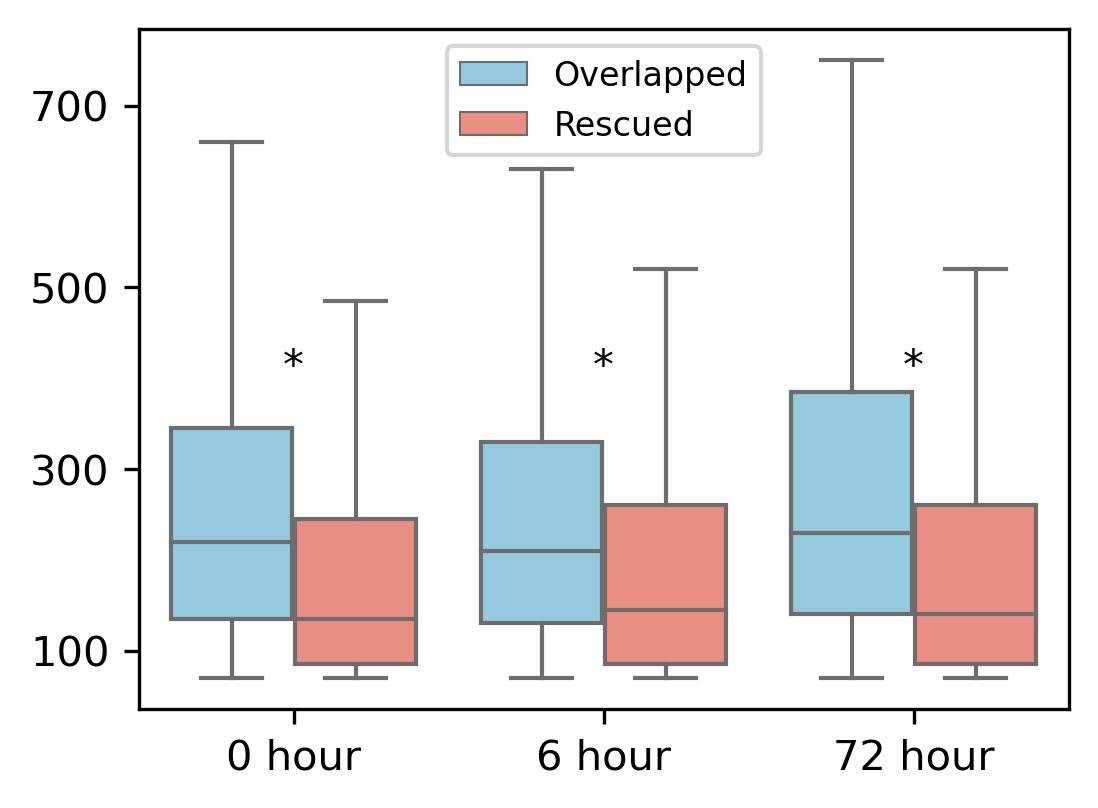

In [53]:
import matplotlib.ticker as ticker

fig = plt.figure(dpi=300, figsize=(4,3))
sns.set_palette(('skyblue','salmon'))
ax=sns.boxplot(x='condition', y='loop_size', hue='method', showfliers=False, linewidth=1, data=loop_size_df)
ax.set(xlabel=None, ylabel=None)
# ax.set_ylabel('Loop size (kb)', size=15)
# ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_yticks(range(100000, 800000, 200000))
ax.set_yticklabels(range(100, 800, 200))
# ax.set_yticks([100000, 130000]+list(range(200000, 800000, 100000)))
# ax.set_yticklabels([100, 120]+list(range(200, 800, 100)), fontsize=15)
ax.set_xticklabels(['0 hour', '6 hour', '72 hour'])
# plt.yscale('log')

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Overlapped', 'Rescued'], loc='upper center', ncol=1, fontsize=8)
# ax.legend_.remove()

# Add text above each x-tick, centered above the two bars
p_labels=['*' if p < 0.05 else '' for p in p_values]
x_positions = ax.get_xticks()
for x, label in zip(x_positions, p_labels):
    ax.text(x, 400000, label, ha='center')
    
# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Bond_et_al_2023/Figures/Figure_4/box_plot_of_size_of_overlapped_and_rescued_loops_Bond_et_al_2023.svg", format='svg', bbox_inches='tight')


# add a horizontal line at 100kb
# ax.axhline(y=130000, color='black', linestyle='--', linewidth=1)